# Autoencoder

## What is an Autoencoder?

An **autoencoder** is an unsupervised neural network that learns to compress data into a lower-dimensional representation (encoding) and then reconstruct the original data from this compressed form.

### Key Components

| Component | Description |
|-----------|-------------|
| **Encoder** | Compresses input data into a compact latent representation |
| **Latent Space (Bottleneck)** | The compressed representation - the "essence" of the data |
| **Decoder** | Reconstructs the original data from the latent representation |
| **Reconstruction Loss** | Measures how well the output matches the input |

### Architecture Overview

```
Input → [Encoder] → Latent Space → [Decoder] → Reconstructed Output
 784      128→64       32           64→128         784
```

### Applications
- **Dimensionality Reduction** - Learning efficient data representations
- **Denoising** - Removing noise from images
- **Anomaly Detection** - Identifying unusual patterns
- **Image Compression** - Learning compact representations
- **Generative Models** - Variational Autoencoders (VAEs) for generating new data

## 1. Setup and Data Loading

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


Training data shape: (60000, 784)
Test data shape: (10000, 784)


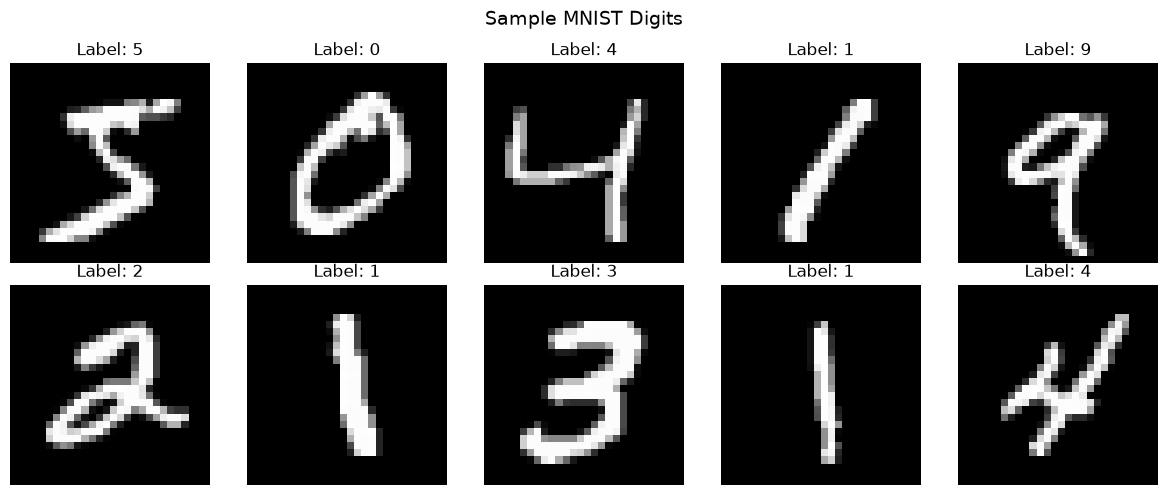

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten 28x28 images to 784-dimensional vectors
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print(f"Training data shape: {x_train_flat.shape}")
print(f"Test data shape: {x_test_flat.shape}")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample MNIST Digits", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Basic Autoencoder

We'll build a simple fully-connected autoencoder with the following architecture:

- **Encoder**: 784 → 128 → 64 → 32 (bottleneck)
- **Decoder**: 32 → 64 → 128 → 784

The bottleneck layer (32 neurons) forces the network to learn a compressed representation.

In [3]:
def build_autoencoder():
    # Encoder
    encoder_input = Input(shape=(784,), name='encoder_input')
    x = layers.Dense(128, activation='relu', name='encoder_dense1')(encoder_input)
    x = layers.Dense(64, activation='relu', name='encoder_dense2')(x)
    encoder_output = layers.Dense(32, activation='relu', name='bottleneck')(x)
    
    # Decoder
    x = layers.Dense(64, activation='relu', name='decoder_dense1')(encoder_output)
    x = layers.Dense(128, activation='relu', name='decoder_dense2')(x)
    decoder_output = layers.Dense(784, activation='sigmoid', name='decoder_output')(x)
    
    # Full autoencoder
    autoencoder = models.Model(encoder_input, decoder_output, name='autoencoder')
    
    # Encoder only (for later use)
    encoder = models.Model(encoder_input, encoder_output, name='encoder')
    
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense1 (Dense)          │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense2 (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Compile the model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['mae']
)

# Train the autoencoder
history = autoencoder.fit(
    x_train_flat, x_train_flat,  # Input = Output (reconstruction)
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2407 - mae: 0.1365 - val_loss: 0.1614 - val_mae: 0.0819
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1470 - mae: 0.0720 - val_loss: 0.1351 - val_mae: 0.0637
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1293 - mae: 0.0597 - val_loss: 0.1219 - val_mae: 0.0548
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1189 - mae: 0.0524 - val_loss: 0.1143 - val_mae: 0.0489
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1127 - mae: 0.0480 - val_loss: 0.1087 - val_mae: 0.0453
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1086 - mae: 0.0451 - val_loss: 0.1052 - val_mae: 0.0428
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1056 - mae: 0.0430 - val_loss: 0.1028 - val_mae: 0.0411
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1030 - mae: 0.0412 - val_loss: 0.1008 - val_mae: 0.0398
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - lo

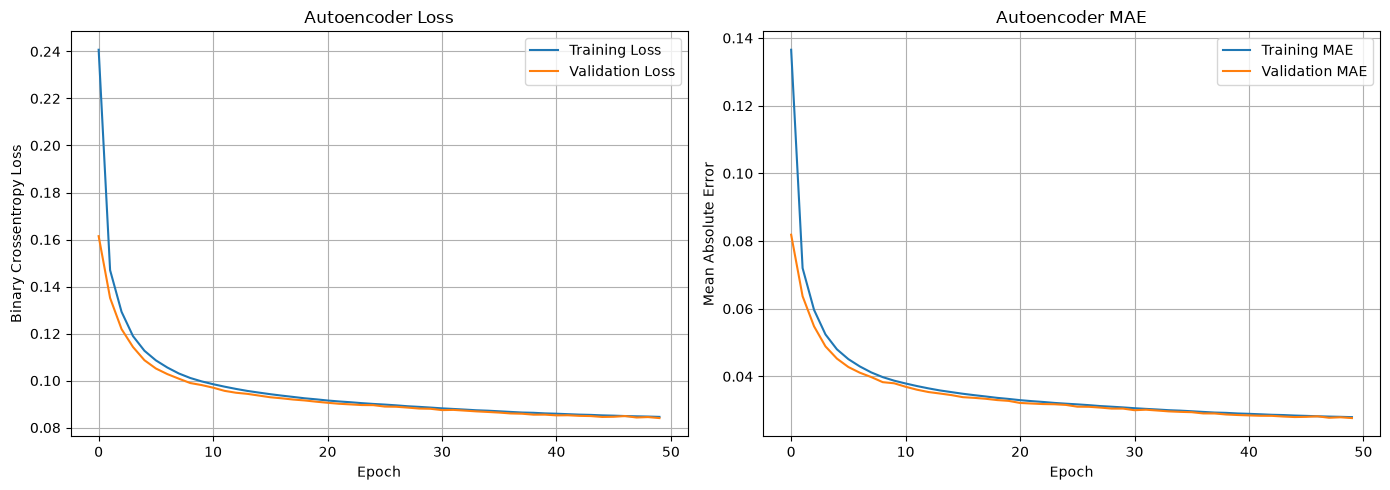

In [5]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Autoencoder Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(True)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Autoencoder MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step


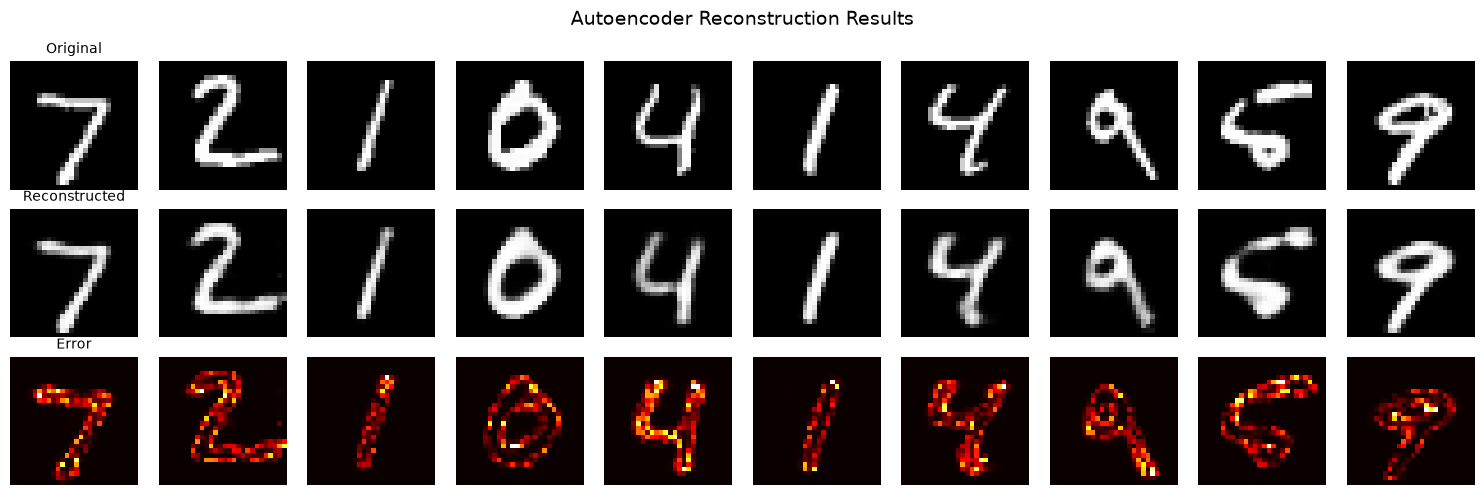

In [6]:
# Visualize reconstructions
reconstructed = autoencoder.predict(x_test_flat)

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for i in range(10):
    # Original images
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)
    
    # Reconstructed images
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=10)
    
    # Difference (error)
    diff = np.abs(x_test[i] - reconstructed[i].reshape(28, 28))
    axes[2, i].imshow(diff, cmap='hot')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Error', fontsize=10)

plt.suptitle('Autoencoder Reconstruction Results', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Latent Space Visualization

The encoder compresses 784-dimensional input into a 32-dimensional latent space. Let's visualize this using dimensionality reduction techniques (PCA and t-SNE).

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step
Latent space shape: (10000, 32)


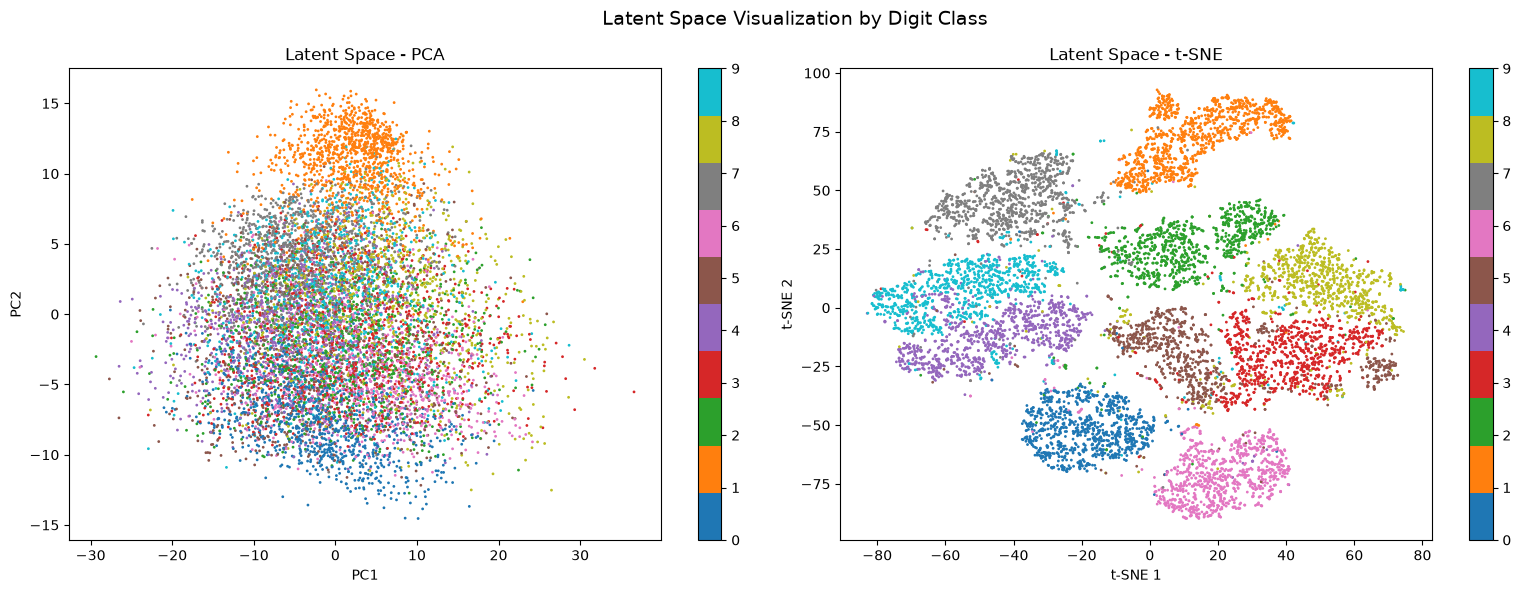

In [7]:
# Extract latent representations
latent_representations = encoder.predict(x_test_flat)
print(f"Latent space shape: {latent_representations.shape}")

# PCA visualization
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_representations)

# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_tsne = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
scatter1 = axes[0].scatter(latent_pca[:, 0], latent_pca[:, 1], c=y_test, cmap='tab10', s=1)
axes[0].set_title('Latent Space - PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# t-SNE plot
scatter2 = axes[1].scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=y_test, cmap='tab10', s=1)
axes[1].set_title('Latent Space - t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1])

plt.suptitle('Latent Space Visualization by Digit Class', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Denoising Autoencoder

A **denoising autoencoder** is trained to reconstruct clean data from noisy inputs. This makes the model more robust and forces it to learn meaningful features rather than just copying the input.

### How it works:
1. Add random noise to the input images
2. Feed the noisy images to the autoencoder
3. Train to reconstruct the **clean** original images

This forces the model to learn the underlying structure of the data.

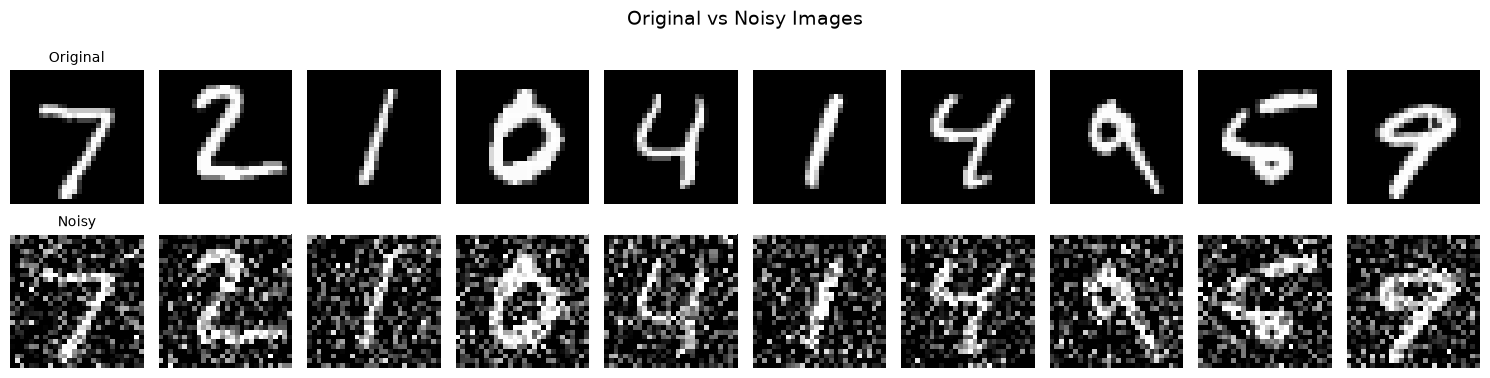

In [8]:
# Add noise to images
noise_factor = 0.4

x_train_noisy = x_train_flat + noise_factor * np.random.normal(size=x_train_flat.shape)
x_test_noisy = x_test_flat + noise_factor * np.random.normal(size=x_test_flat.shape)

# Clip values to [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

# Visualize noisy samples
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)
    
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Noisy', fontsize=10)

plt.suptitle('Original vs Noisy Images', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
def build_denoising_autoencoder():
    # Encoder
    encoder_input = Input(shape=(784,), name='encoder_input')
    x = layers.Dense(128, activation='relu', name='encoder_dense1')(encoder_input)
    x = layers.Dense(64, activation='relu', name='encoder_dense2')(x)
    encoder_output = layers.Dense(32, activation='relu', name='bottleneck')(x)
    
    # Decoder
    x = layers.Dense(64, activation='relu', name='decoder_dense1')(encoder_output)
    x = layers.Dense(128, activation='relu', name='decoder_dense2')(x)
    decoder_output = layers.Dense(784, activation='sigmoid', name='decoder_output')(x)
    
    # Full denoising autoencoder
    denoising_autoencoder = models.Model(encoder_input, decoder_output, name='denoising_autoencoder')
    
    return denoising_autoencoder

denoising_autoencoder = build_denoising_autoencoder()
denoising_autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense1 (Dense)          │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense2 (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the denoising autoencoder
denoising_autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['mae']
)

# Train: input is noisy, target is clean
history_denoising = denoising_autoencoder.fit(
    x_train_noisy, x_train_flat,  # Noisy input → Clean output
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_flat)
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2657 - mae: 0.1526 - val_loss: 0.1976 - val_mae: 0.1066
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1774 - mae: 0.0924 - val_loss: 0.1623 - val_mae: 0.0823
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1577 - mae: 0.0786 - val_loss: 0.1518 - val_mae: 0.0752
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1493 - mae: 0.0730 - val_loss: 0.1446 - val_mae: 0.0698
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1429 - mae: 0.0686 - val_loss: 0.1392 - val_mae: 0.0662
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1376 - mae: 0.0650 - val_loss: 0.1341 - val_mae: 0.0624
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1332 - mae: 0.0619 - val_loss: 0.1306 - val_mae: 0.0601
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1299 - mae: 0.0596 - val_loss: 0.1278 - val_mae: 0.0583
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - lo

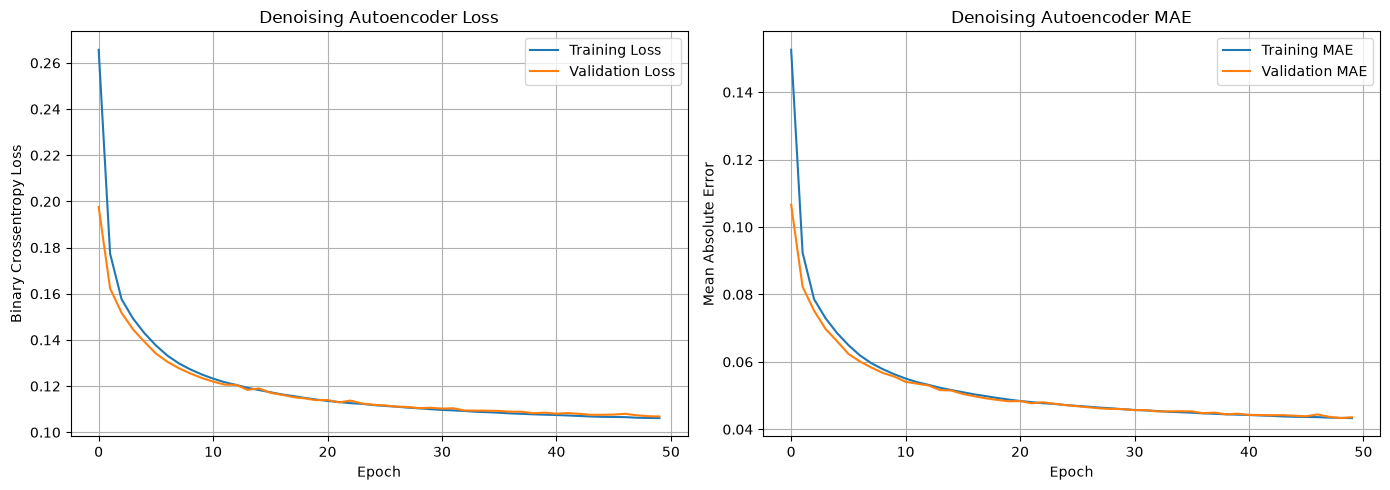

In [11]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history_denoising.history['loss'], label='Training Loss')
axes[0].plot(history_denoising.history['val_loss'], label='Validation Loss')
axes[0].set_title('Denoising Autoencoder Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(True)

# MAE plot
axes[1].plot(history_denoising.history['mae'], label='Training MAE')
axes[1].plot(history_denoising.history['val_mae'], label='Validation MAE')
axes[1].set_title('Denoising Autoencoder MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step


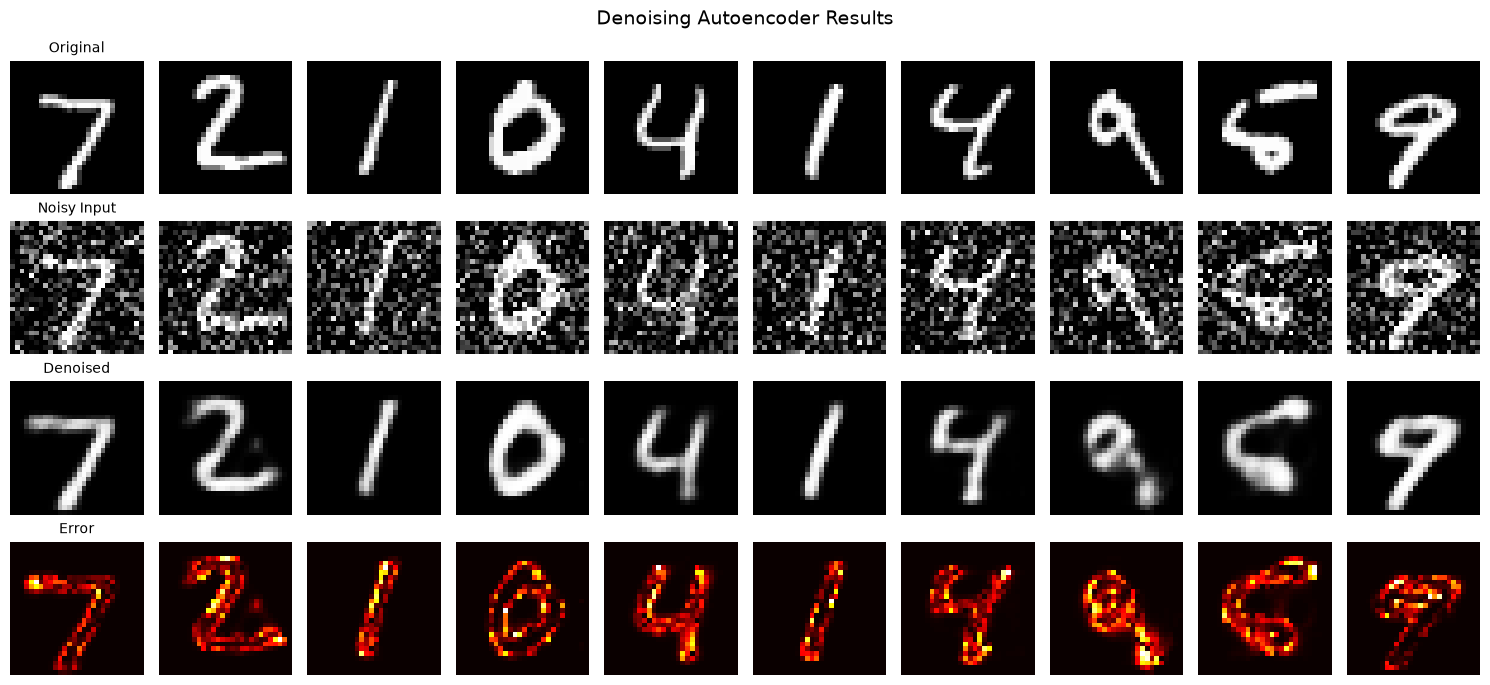

In [12]:
# Visualize denoising results
denoised = denoising_autoencoder.predict(x_test_noisy)

fig, axes = plt.subplots(4, 10, figsize=(15, 7))
for i in range(10):
    # Original clean images
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)
    
    # Noisy images
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Noisy Input', fontsize=10)
    
    # Denoised images
    axes[2, i].imshow(denoised[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Denoised', fontsize=10)
    
    # Error (original vs denoised)
    diff = np.abs(x_test[i] - denoised[i].reshape(28, 28))
    axes[3, i].imshow(diff, cmap='hot')
    axes[3, i].axis('off')
    if i == 0:
        axes[3, i].set_title('Error', fontsize=10)

plt.suptitle('Denoising Autoencoder Results', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Comparison: Basic vs Denoising Autoencoder

Let's compare the reconstruction quality of both autoencoders.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step


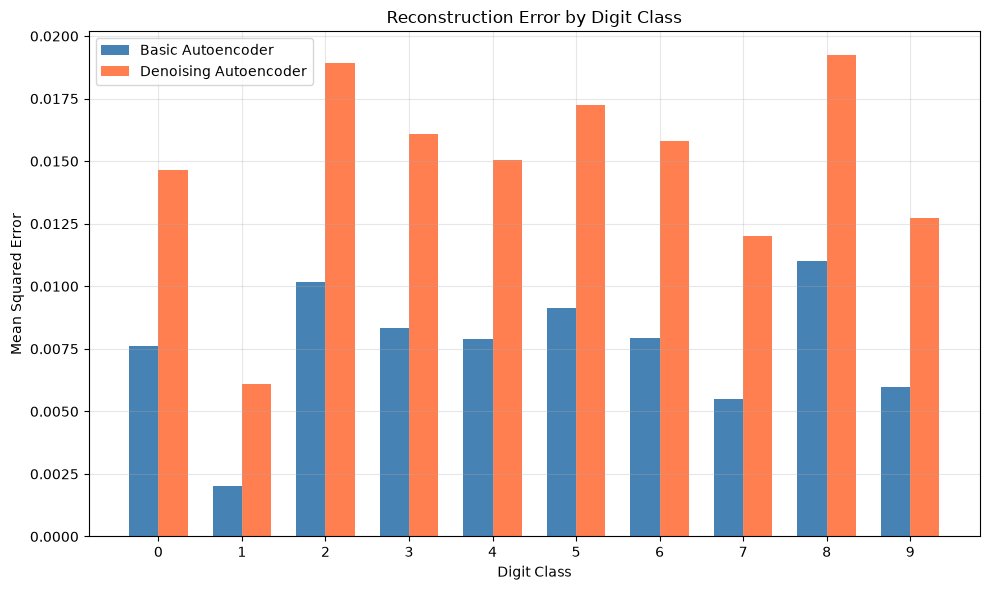


Overall MSE - Basic AE: 0.007555
Overall MSE - Denoising AE: 0.014778


In [13]:
# Get reconstructions from both models
recon_basic = autoencoder.predict(x_test_flat)
recon_denoising = denoising_autoencoder.predict(x_test_noisy)

# Calculate MSE for each digit class
from sklearn.metrics import mean_squared_error

mse_basic = []
mse_denoising = []
classes = range(10)

for c in classes:
    mask = y_test == c
    
    # Basic AE
    mse_b = mean_squared_error(x_test_flat[mask], recon_basic[mask])
    mse_basic.append(mse_b)
    
    # Denoising AE (compare to clean)
    mse_d = mean_squared_error(x_test_flat[mask], recon_denoising[mask])
    mse_denoising.append(mse_d)

# Plot comparison
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, mse_basic, width, label='Basic Autoencoder', color='steelblue')
bars2 = ax.bar(x + width/2, mse_denoising, width, label='Denoising Autoencoder', color='coral')

ax.set_xlabel('Digit Class')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Reconstruction Error by Digit Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOverall MSE - Basic AE: {np.mean(mse_basic):.6f}")
print(f"Overall MSE - Denoising AE: {np.mean(mse_denoising):.6f}")

## Summary

### Key Takeaways

| Aspect | Basic Autoencoder | Denoising Autoencoder |
|--------|-------------------|------------------------|
| **Training** | Input = Output | Noisy Input → Clean Output |
| **Purpose** | Dimensionality reduction, feature learning | Noise removal, robust features |
| **Latent Space** | Captures essential features | Captures invariant features |
| **Use Cases** | Compression, anomaly detection | Image denoising, preprocessing |

### When to Use Autoencoders
- **Dimensionality Reduction**: When you need compact data representations
- **Anomaly Detection**: When anomalies have high reconstruction error
- **Denoising**: When data contains noise that needs removal
- **Feature Learning**: When you need meaningful features for downstream tasks
- **Pretraining**: When you want to initialize deep networks

### Next Steps
- Try different bottleneck sizes (2, 8, 16, 64) to see the trade-off
- Experiment with convolutional autoencoders for images
- Explore Variational Autoencoders (VAEs) for generative modeling
- Apply to real-world datasets (CIFAR-10, medical images, etc.)